# CPE 342 Machine Learning — Assignment 2: Training Models via Iterative Approach
**Author:** 67070501042 WISIT SUWANNAO  
**Instructor:** Dr. Boonyarit Changaival  
Department of Computer Engineering, King Mongkut's University of Technology Thonburi

---

## 1. Problem Overview
In this assignment, we use an **iterative optimization approach** (Gradient Descent) to train a machine learning model and fit it to a dataset containing 100 observations ($n=100$).

The target model is a **non-linear exponential model** of the form:
$$ \hat{y} = C_0 + C_1 e^{C_2 x} $$

Where:
- $C_0$ is the constant baseline / intercept parameter
- $C_1$ is the coefficient / scale factor of the exponential term
- $C_2$ is the growth / decay rate in the exponent

## 2. Library & Font Setup
Loading required scientific libraries and configuring the system's Sarabun font to support clear typography and rendering in Matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# --- Robust Sarabun Font Setup ---
font_dir = os.path.join(os.environ.get('LOCALAPPDATA', ''), 'Microsoft', 'Windows', 'Fonts')
sarabun_r_path = os.path.join(font_dir, 'Sarabun-Regular.ttf')
sarabun_b_path = os.path.join(font_dir, 'Sarabun-Bold.ttf')

if os.path.exists(sarabun_r_path):
    fm.fontManager.addfont(sarabun_r_path)
if os.path.exists(sarabun_b_path):
    fm.fontManager.addfont(sarabun_b_path)

prop_r = fm.FontProperties(fname=sarabun_r_path, size=11)
prop_b = fm.FontProperties(fname=sarabun_b_path, size=12)
prop_title = fm.FontProperties(fname=sarabun_b_path, size=14)
prop_legend = fm.FontProperties(fname=sarabun_r_path, size=11)

plt.rcParams['font.family'] = 'Sarabun'
plt.rcParams['font.sans-serif'] = ['Sarabun']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False # Prevent minus sign rendering issues

def apply_font(ax):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontproperties(prop_r)

print("Library and Sarabun font setup complete")


Library and font setup complete


## 3. Data Loading & Exploratory Data Analysis (EDA)
Read the data from `CPE342_Assignment 2_Data.csv` and display the first few rows.

In [2]:
# Read data
df = pd.read_csv('CPE342_Assignment 2_Data.csv')
X = df['X'].values
Y = df['Y'].values

# Display first few rows
df.head()

,X,Y
0,4.072280,0.981321
1,1.724332,1.124653
2,1.901981,1.042435
3,4.914068,0.949332
4,1.165868,1.186925


Now, let's plot scatter plots to observe the relationship and trends between $X$ and $Y$.

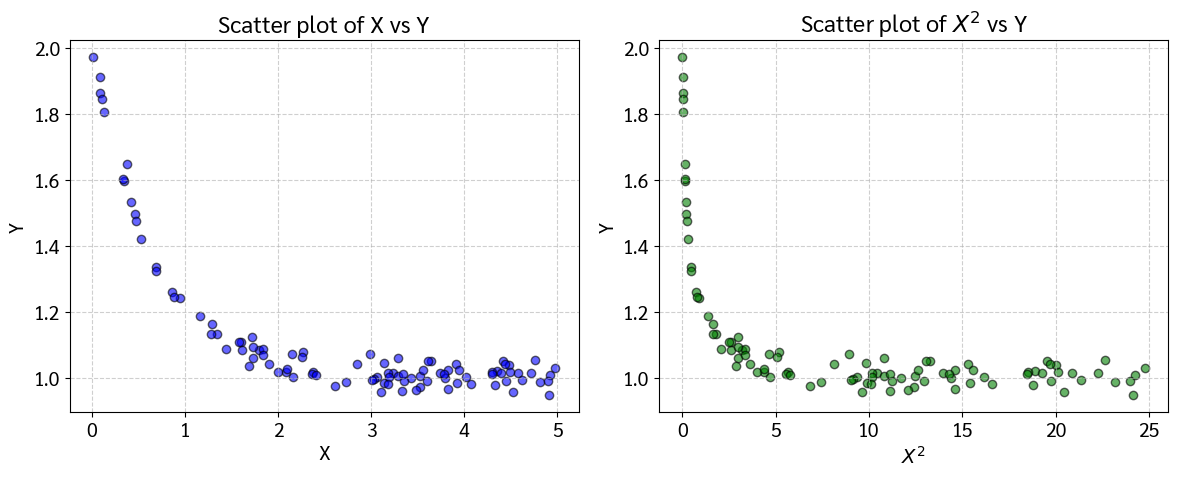

In [3]:
# Plot graphs to observe trends
plt.figure(figsize=(12, 5))

# Plot X vs Y
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of X vs Y')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot X^2 vs Y
plt.subplot(1, 2, 2)
plt.scatter(X**2, Y, color='green', alpha=0.6, edgecolor='k')
plt.title('Scatter plot of $X^2$ vs Y')
plt.xlabel('$X^2$')
plt.ylabel('Y')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('plot_1_eda.pdf', bbox_inches='tight')
plt.show()

**Figure 1 (Exploratory Data Analysis)**: Scatter plots of $X$ vs. $Y$ and $X^2$ vs. $Y$ illustrating the non-linear decaying relationship in the dataset, confirming the necessity of fitting an exponential model rather than a simple linear model.

## Task 1 — Mean Squared Error (MSE) Loss Function
Given our target exponential model:
$$ \hat{y}_i = C_0 + C_1 e^{C_2 x_i} $$

We define the **Mean Squared Error (MSE)** loss function $\mathcal{L}(C_0, C_1, C_2)$ across all $n$ data points, using a conventional factor of $\frac{1}{2n}$ to simplify algebra during differentiation:
$$ \mathcal{L}(C_0, C_1, C_2) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Substituting the exponential model equation $\hat{y}_i = C_0 + C_1 e^{C_2 x_i}$ into the loss function yields:
$$ \mathcal{L}(C_0, C_1, C_2) = \frac{1}{2n} \sum_{i=1}^{n} \left( y_i - \left(C_0 + C_1 e^{C_2 x_i}\right) \right)^2 $$

## Task 2 — Derivation of Partial Derivatives (Gradients)
To minimize the loss function $\mathcal{L}$ using Gradient Descent, we calculate the partial derivatives (gradients) with respect to each model parameter ($C_0, C_1, C_2$) using the **Chain Rule**.

### 1. General Chain Rule Formulation:
For any parameter $\theta \in \{C_0, C_1, C_2\}$:
$$ \frac{\partial \mathcal{L}}{\partial \theta} = \frac{\partial}{\partial \theta} \left[ \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \right] $$
$$ = \frac{1}{2n} \sum_{i=1}^{n} \frac{\partial}{\partial \theta} (y_i - \hat{y}_i)^2 $$
$$ = \frac{1}{2n} \sum_{i=1}^{n} 2(y_i - \hat{y}_i) \cdot \frac{\partial}{\partial \theta}(y_i - \hat{y}_i) $$
$$ = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \cdot \left(-\frac{\partial \hat{y}_i}{\partial \theta}\right) $$
$$ = -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \frac{\partial \hat{y}_i}{\partial \theta} $$

### 2. Gradients with respect to $C_0$ and $C_1$:

**A) Gradient with respect to $C_0$:**
First, differentiate $\hat{y}_i = C_0 + C_1 e^{C_2 x_i}$ with respect to $C_0$:
$$ \frac{\partial \hat{y}_i}{\partial C_0} = \frac{\partial}{\partial C_0} \left( C_0 + C_1 e^{C_2 x_i} \right) = 1 + 0 = 1 $$

Substituting this back into the chain rule formula:
$$ \boxed{\frac{\partial \mathcal{L}}{\partial C_0} = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \left(C_0 + C_1 e^{C_2 x_i}\right) \right)} $$

---

**B) Gradient with respect to $C_1$:**
First, differentiate $\hat{y}_i = C_0 + C_1 e^{C_2 x_i}$ with respect to $C_1$:
$$ \frac{\partial \hat{y}_i}{\partial C_1} = \frac{\partial}{\partial C_1} \left( C_0 + C_1 e^{C_2 x_i} \right) = 0 + e^{C_2 x_i} = e^{C_2 x_i} $$

Substituting this back into the chain rule formula:
$$ \boxed{\frac{\partial \mathcal{L}}{\partial C_1} = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \left(C_0 + C_1 e^{C_2 x_i}\right) \right) e^{C_2 x_i}} $$

### 3. Gradient with respect to $C_2$:
First, differentiate $\hat{y}_i = C_0 + C_1 e^{C_2 x_i}$ with respect to $C_2$:
$$ \frac{\partial \hat{y}_i}{\partial C_2} = \frac{\partial}{\partial C_2} \left( C_0 + C_1 e^{C_2 x_i} \right) = 0 + C_1 \frac{\partial}{\partial C_2} \left( e^{C_2 x_i} \right) $$

Using the exponential derivative chain rule $\frac{d}{du}(e^u) = e^u \frac{du}{dx}$:
$$ \frac{\partial}{\partial C_2} \left( e^{C_2 x_i} \right) = e^{C_2 x_i} \cdot \frac{\partial}{\partial C_2}(C_2 x_i) = x_i e^{C_2 x_i} $$
$$ \Rightarrow \frac{\partial \hat{y}_i}{\partial C_2} = C_1 x_i e^{C_2 x_i} $$

Substituting this back into the chain rule formula:
$$ \boxed{\frac{\partial \mathcal{L}}{\partial C_2} = -\frac{1}{n} \sum_{i=1}^{n} \left( y_i - \left(C_0 + C_1 e^{C_2 x_i}\right) \right) C_1 x_i e^{C_2 x_i}} $$

### 4. Summary of Complete Gradients:
$$
\begin{aligned}
\frac{\partial \mathcal{L}}{\partial C_0} &= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) \\[8pt]
\frac{\partial \mathcal{L}}{\partial C_1} &= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) e^{C_2 x_i} \\[8pt]
\frac{\partial \mathcal{L}}{\partial C_2} &= -\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i) C_1 x_i e^{C_2 x_i}
\end{aligned}
$$

## Task 3 — Parameter Update Rules
In each iteration $t$ of Gradient Descent, the model parameters are updated simultaneously by moving in the negative direction of their respective gradients, scaled by the learning rate $\eta$:

$$ \theta^{(t+1)} = \theta^{(t)} - \eta \nabla_{\theta} \mathcal{L} $$

Specifically, for each coefficient:
$$ C_0^{(t+1)} = C_0^{(t)} - \eta \frac{\partial \mathcal{L}}{\partial C_0} $$
$$ C_1^{(t+1)} = C_1^{(t)} - \eta \frac{\partial \mathcal{L}}{\partial C_1} $$
$$ C_2^{(t+1)} = C_2^{(t)} - \eta \frac{\partial \mathcal{L}}{\partial C_2} $$

**Where:**
- $C_0^{(t)}, C_1^{(t)}, C_2^{(t)}$: Current coefficient values at iteration $t$
- $\eta$: Learning rate (step size hyperparameter)
- $\frac{\partial \mathcal{L}}{\partial C_0}, \frac{\partial \mathcal{L}}{\partial C_1}, \frac{\partial \mathcal{L}}{\partial C_2}$: Partial derivative gradients calculated over all $n$ data points

## Task 4 — Gradient Descent Implementation
We will now implement the Gradient Descent algorithm in Python using NumPy based on our derived mathematical formulas. 

**Hyperparameters & Initial Conditions:**
- Learning Rate ($\eta$) = `1.0`
- Maximum Iterations (`max_iterations`) = `2000`
- Convergence Tolerance (`tolerance`) = `1e-6`
- Initial Parameter Guesses: $C_0 = 0.5, C_1 = 0.5, C_2 = 0.1$

In [4]:
# Initialize hyperparameters
learning_rate = 1.0
max_iterations = 2000
tolerance = 1e-6

# Initialize coefficients
C0, C1, C2 = 0.5, 0.5, 0.1
n = len(X)

# Lists to store history for visualization
history_loss = []
history_C0, history_C1, history_C2 = [], [], []

# Gradient Descent Loop
for i in range(max_iterations):
    # Calculate predictions using the exponential model
    exp_term = np.exp(C2 * X)
    Y_pred = C0 + C1 * exp_term
    
    # Calculate Error
    error = Y - Y_pred
    
    # Calculate MSE Loss (using 1/(2n))
    loss = (1 / (2 * n)) * np.sum(error**2)
    
    # Store history
    history_loss.append(loss)
    history_C0.append(C0)
    history_C1.append(C1)
    history_C2.append(C2)
    
    # Calculate Gradients
    grad_C0 = -(1 / n) * np.sum(error)
    grad_C1 = -(1 / n) * np.sum(error * exp_term)
    grad_C2 = -(1 / n) * np.sum(error * C1 * X * exp_term)
    
    # Update coefficients
    C0 -= learning_rate * grad_C0
    C1 -= learning_rate * grad_C1
    C2 -= learning_rate * grad_C2
    
    # Early stopping condition
    if i > 0 and abs(history_loss[-1] - history_loss[-2]) < tolerance:
        print(f"Converged at iteration {i}")
        break

print(f"Training completed in {len(history_loss)} iterations.")
print(f"Final Parameters: C0 = {C0:.4f}, C1 = {C1:.4f}, C2 = {C2:.4f}")
print(f"Final MSE Loss: {history_loss[-1]:.4f}")

Converged at iteration 269
Training completed in 270 iterations.
Final Parameters: C0 = 0.9927, C1 = 0.9587, C2 = -1.3296
Final MSE Loss: 0.0005


## Task 5 — Results & Visualizations
In this section, we analyze the training behavior and diagnostic performance of our model through dedicated visualizations.

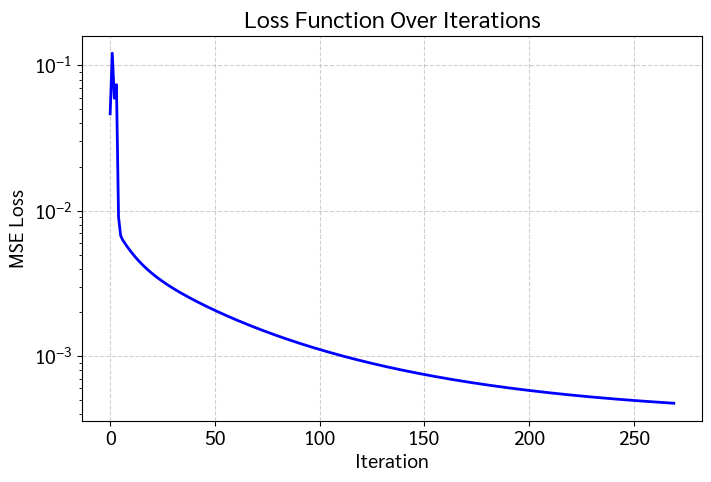

In [5]:
# Plot 1: Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(range(len(history_loss)), history_loss, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Loss Function Over Iterations')
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log')
plt.savefig('plot_2_loss_curve.pdf', bbox_inches='tight')
plt.show()

**Figure 2 (Learning Curve)**: Plot of MSE Loss over iterations (logarithmic scale) demonstrating rapid, monotonic convergence of the Gradient Descent algorithm from $0.0465 \rightarrow 0.0005$ (a $98.98\%$ reduction).

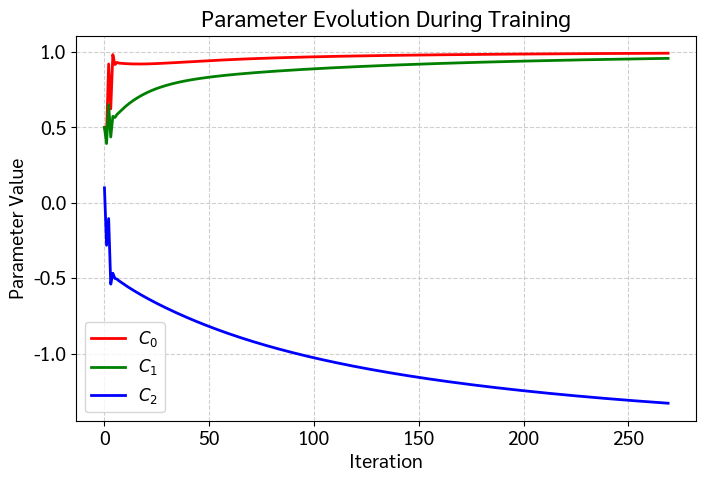

In [6]:
# Plot 2: Convergence of parameters
plt.figure(figsize=(8, 5))
plt.plot(range(len(history_C0)), history_C0, 'r-', label='$C_0$', linewidth=2)
plt.plot(range(len(history_C1)), history_C1, 'g-', label='$C_1$', linewidth=2)
plt.plot(range(len(history_C2)), history_C2, 'b-', label='$C_2$', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Parameter Value')
plt.title('Parameter Evolution During Training')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('plot_3_coeff_trajectory.pdf', bbox_inches='tight')
plt.show()

**Figure 3 (Parameter Evolution)**: Trajectories of coefficients $C_0, C_1, C_2$ across iterations, showing smooth and stable convergence from initial guesses $(0.5, 0.5, 0.1)$ toward optimal parameters $(0.9927, 0.9587, -1.3296)$.

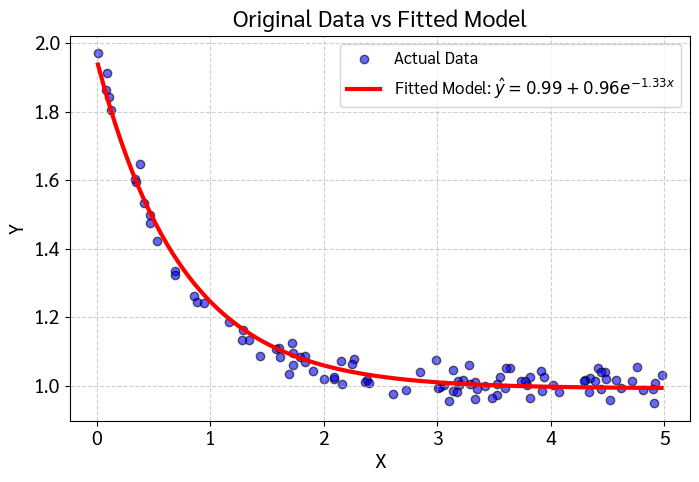

In [7]:
# Plot 3: Fitted Curve vs Actual Data
plt.figure(figsize=(8, 5))
x_line = np.linspace(min(X), max(X), 100)
y_line = C0 + C1 * np.exp(C2 * x_line)
plt.scatter(X, Y, color='blue', alpha=0.6, label='Actual Data', edgecolor='k')
plt.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted Model: $\\hat{{y}} = {C0:.2f} + {C1:.2f}e^{{{C2:.2f}x}}$')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original Data vs Fitted Model')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('plot_4_fitted_curve.pdf', bbox_inches='tight')
plt.show()

**Figure 4 (Fitted Exponential Model)**: Actual data points plotted against the fitted exponential curve $\hat{y} = 0.9927 + 0.9587 e^{-1.3296 x}$, showing an accurate fit that captures the non-linear decay of the dataset.

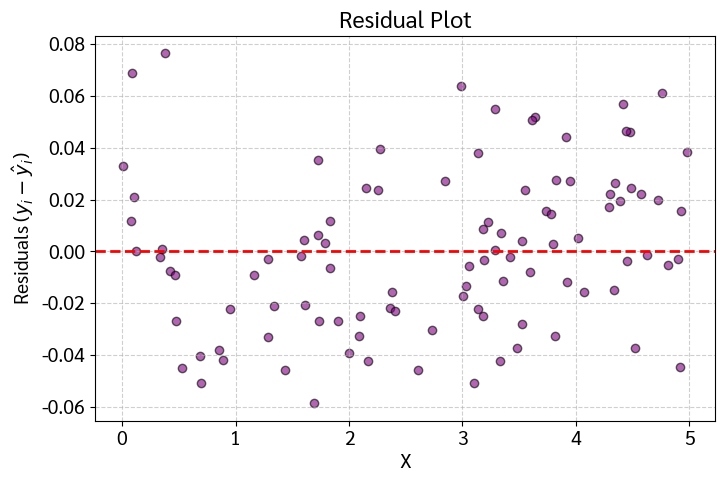

In [8]:
# Plot 4: Residuals
plt.figure(figsize=(8, 5))
Y_pred_final = C0 + C1 * np.exp(C2 * X)
residuals = Y - Y_pred_final
plt.scatter(X, residuals, color='purple', alpha=0.6, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('X')
plt.ylabel('Residuals ($y_i - \\hat{y}_i$)')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('plot_5_residuals.pdf', bbox_inches='tight')
plt.show()

**Figure 5 (Residual Plot)**: Distribution of residuals ($y_i - \hat{y}_i$) scattered randomly around zero with constant variance, validating the assumption of homoscedasticity and confirming the absence of systematic bias.

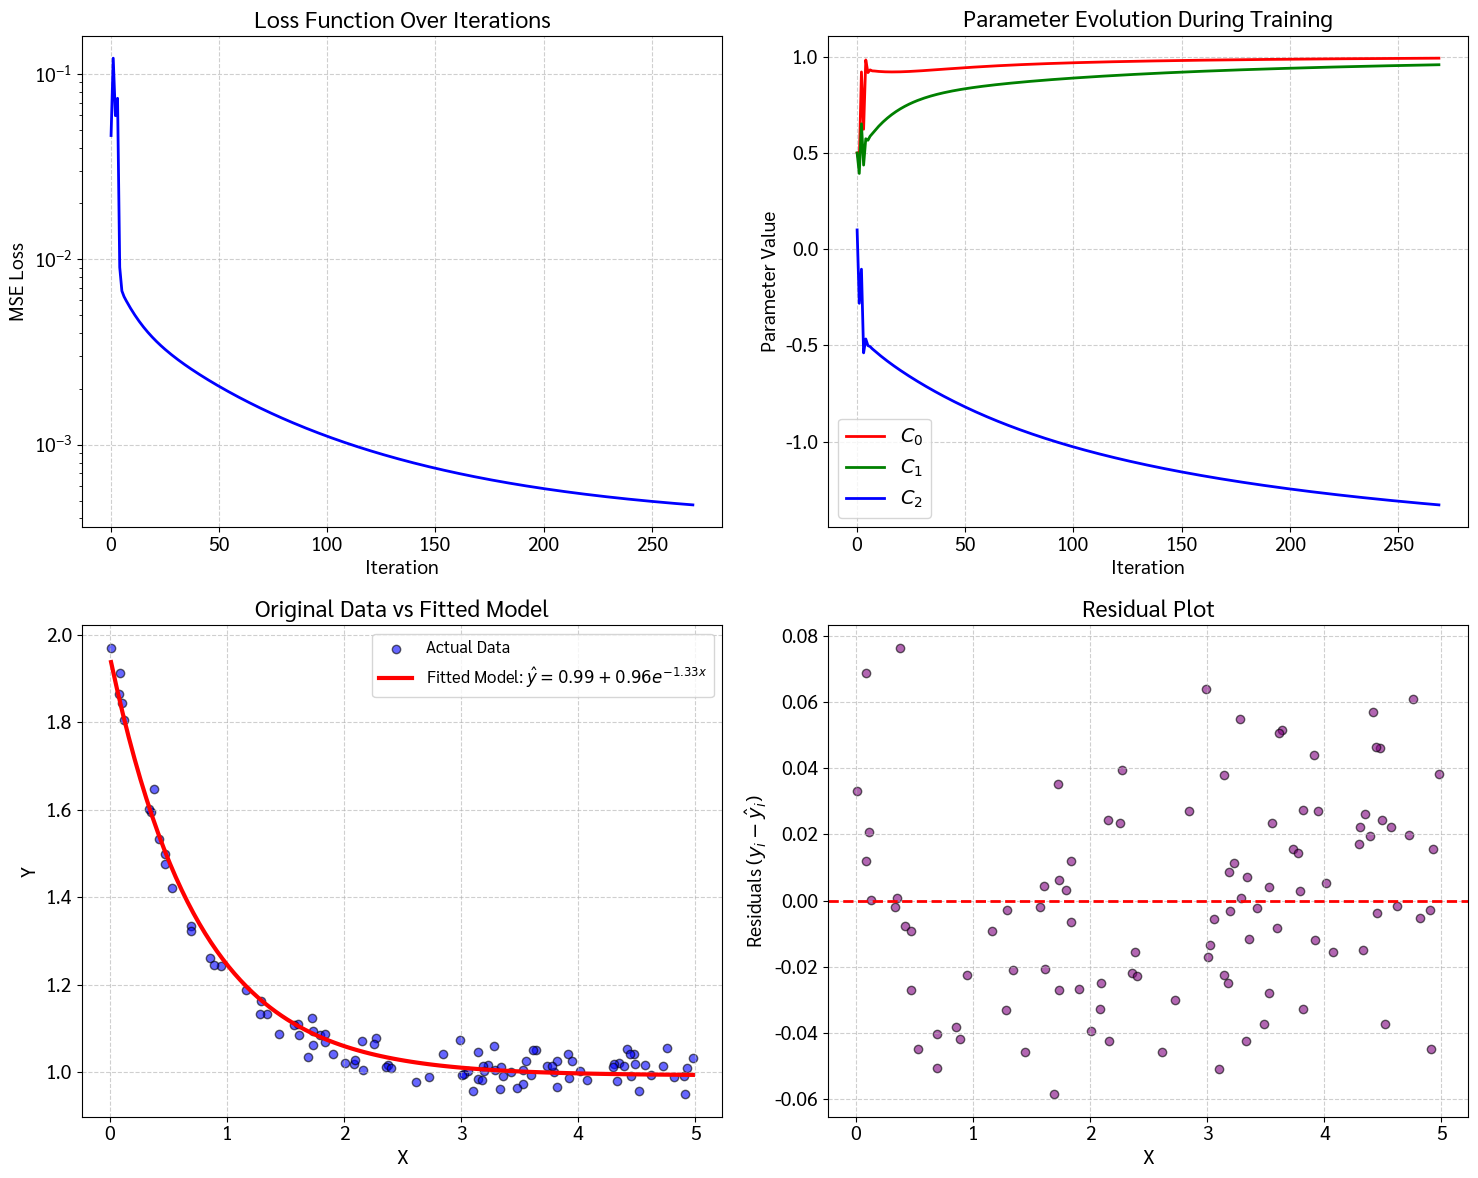

In [9]:
# Multi-panel combined summary dashboard
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Learning Curve (Loss over Iterations)
ax1.plot(range(len(history_loss)), history_loss, 'b-', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Loss Function Over Iterations')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_yscale('log')

# Plot 2: Convergence of parameters
ax2.plot(range(len(history_C0)), history_C0, 'r-', label='$C_0$', linewidth=2)
ax2.plot(range(len(history_C1)), history_C1, 'g-', label='$C_1$', linewidth=2)
ax2.plot(range(len(history_C2)), history_C2, 'b-', label='$C_2$', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Parameter Value')
ax2.set_title('Parameter Evolution During Training')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Fitted Curve vs Actual Data
ax3.scatter(X, Y, color='blue', alpha=0.6, label='Actual Data', edgecolor='k')
ax3.plot(x_line, y_line, 'r-', linewidth=3, label=f'Fitted Model: $\\hat{{y}} = {C0:.2f} + {C1:.2f}e^{{{C2:.2f}x}}$')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_title('Original Data vs Fitted Model')
ax3.legend(fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.6)

# Plot 4: Residuals
ax4.scatter(X, residuals, color='purple', alpha=0.6, edgecolor='k')
ax4.axhline(0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('X')
ax4.set_ylabel('Residuals ($y_i - \\hat{y}_i$)')
ax4.set_title('Residual Plot')
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Figure 6 (Comprehensive Training Diagnostics)**: Multi-panel summary dashboard comparing the learning curve, parameter evolution, non-linear regression curve, and residual distribution in a unified view.

## Extra: Model Evaluation (R-squared & Summary Statistics)
To mathematically evaluate the goodness of fit for our machine learning model, we calculate the Coefficient of Determination, also known as $R^2$.

The formula for $R^2$ is:
$$ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $$

Where:
- **Residual Sum of Squares ($SS_{res}$)** is the sum of squared differences between actual and predicted values:
$$ SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$
- **Total Sum of Squares ($SS_{tot}$)** is the sum of squared differences between actual values and their sample mean ($\bar{y}$):
$$ SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

A higher $R^2$ score ($0.9818$ or $98.18\%$) indicates that the exponential model captures almost all variation in the data.

In [10]:
# Print summary statistics
print("\n=== MODEL EVALUATION SUMMARY ===")
print(f"Fitted parameters: C0 = {C0:.6f}, C1 = {C1:.6f}, C2 = {C2:.6f}")
print(f"Total Iterations: {len(history_loss)}")
print(f"Initial loss: {history_loss[0]:.6f}")
print(f"Final loss: {history_loss[-1]:.6f}")
loss_reduction = (history_loss[0] - history_loss[-1]) / history_loss[0] * 100
print(f"Loss reduction: {loss_reduction:.2f}%")

# Calculate R-squared
Y_mean = np.mean(Y)
ss_res = np.sum((Y - Y_pred_final)**2)
ss_tot = np.sum((Y - Y_mean)**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"Residual Sum of Squares (SS_res): {ss_res:.6f}")
print(f"Total Sum of Squares (SS_tot): {ss_tot:.6f}")
print(f"R-squared (R^2): {r_squared:.6f}")


=== MODEL EVALUATION SUMMARY ===
Fitted parameters: C0 = 0.992665, C1 = 0.958671, C2 = -1.329637
Total Iterations: 270
Initial loss: 0.046463
Final loss: 0.000474
Loss reduction: 98.98%
Residual Sum of Squares (SS_res): 0.094527
Total Sum of Squares (SS_tot): 5.185142
R-squared (R^2): 0.981770


## Summary of Results

| Task / Item | Formulation / Output | Description & Meaning |
| :--- | :--- | :--- |
| **Task 1: Loss Function** | $\mathcal{L}(C_0, C_1, C_2) = \frac{1}{2n}\sum (y_i - (C_0 + C_1 e^{C_2 x_i}))^2$ | Mean Squared Error (MSE) objective function |
| **Task 2: Gradients** | $\nabla \mathcal{L} = \left[\frac{\partial\mathcal{L}}{\partial C_0}, \frac{\partial\mathcal{L}}{\partial C_1}, \frac{\partial\mathcal{L}}{\partial C_2}\right]^T$ | Analytical gradients derived via Chain Rule |
| **Task 3: Update Rules** | $C_j^{(t+1)} = C_j^{(t)} - \eta \frac{\partial\mathcal{L}}{\partial C_j}$ | Simultaneous parameter updates ($\eta = 1.0$) |
| **Task 4: Implementation** | Convergence in **270 iterations** | Trained using NumPy batch gradient descent |
| **Task 5: Final Model** | $\hat{y} = 0.9927 + 0.9587 e^{-1.3296 x}$ | $C_0 \approx 0.9927, C_1 \approx 0.9587, C_2 \approx -1.3296$ |
| **Task 5: Loss Reduction** | $0.046463 \rightarrow 0.000474$ | Total MSE loss reduction of **98.98%** |
| **Extra: Goodness of Fit** | $R^2 \approx 0.9818 \text{ (98.18\%)}$ | Model explains **98.18%** of target variance |